In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
import plotly.express as px

In [9]:
gt_op = pd.read_csv('../../data/raw/ehn_gt_outpatient_20251223000.csv')

In [12]:
gt_op.head()

,eventdate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,...,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicing_practice,servicing_lhn,servicing_entity
0,2024-01-01,0d37b3ac08dc91071b27d1d893198589,Emory Anthem Commercial,SHARPSBURG,GA,30277,1629307277,"LEWIS, BRIAN",EHN,EHN Employed,...,87426,IAAD IA SEVERE AQT RESPIR SYND CORONAVIRUS,J06.9,"Acute upper respiratory infection, unspecified",1.972779e+09,Emergency Medicine,LAB,Emory at Sharpsburg,SC,ESA
1,2024-01-01,0c8c2c1ae73541addaea18e9e729a4b7,Emory Humana MAdv,LOGANVILLE,GA,30052,1568576866,"DEIMLER, ROBERT",EHN,EHN Employed,...,NaN,NaN,N18.6,End stage renal disease,NaN,NaN,MEDICAL PHARMACY,Emory at Centerville,EDH,ESA
2,2024-01-01,3abc08ca4f28e8c6ee5ac81a17cdea18,Emory Aetna MAdv,STONE MOUNTAIN,GA,30087,1326027715,"KIM, SHAWN",EHN,EHN Independent,...,S9083,Global fee urgent care centers,R05.9,"Cough, unspecified",1.720487e+09,Clinic/Center,OTHER,GA Internal Medicine,EJCH,PRIVATE
3,2024-01-01,f6fc7f2fa57ce4ae5ba7c7a185e1ab8c,Emory Cigna Commercial,STONE MOUNTAIN,GA,30088,1902990336,"PATEL, DHARMESHKUMAR",EHN,EHN Independent,...,87661,IADNA TRICHOMONAS VAGINALIS AMPLIFIED PROBE TECH,A64,Unspecified sexually transmitted disease,1.932166e+09,Clinical Medical Laboratory,LAB,"Georgia Family Care, LLC",EDH,PRIVATE
4,2024-01-01,8c0945a484fafaf39bf33361ff55b0ba,Emory Anthem MAdv,COLUMBUS,GA,31904,1821483488,"ALLAWY, ALLAWY",EHN,EHN Independent,...,99458,REMOTE PHYSIOLOGIC MONITORING EA ADDL 20 MIN MO,I10,Essential (primary) hypertension,1.881776e+09,Family Medicine,PCP VISITS,Unknown,Unknown,Unknown


In [13]:
gt_op.columns

Index(['eventdate', 'deid_personid', 'planpayer', 'patient_city',
       'patient_state', 'patient_zip', 'pcpnpi', 'pcpname', 'ehn_vs_non',
       'employed_vs_independent', 'ehn_practice', 'lhn', 'entity', 'cost',
       'paiddate', 'placeofservice', 'placeofservicedescription',
       'primary_cpt', 'cptdescription', 'primary_icd', 'icddescription',
       'servicing_prov', 'servicing_specialty', 'rptgrouper',
       'servicing_practice', 'servicing_lhn', 'servicing_entity'],
      dtype='object')

In [14]:
gt_op['deid_personid'] = gt_op['deid_personid'].astype(str)
gt_op['eventdate'] = pd.to_datetime(gt_op['eventdate'], errors='coerce')
gt_op['cost'] = pd.to_numeric(gt_op['cost'], errors='coerce').fillna(0)

In [9]:
## Common columns between the three dataframes

In [15]:
# Shapes of the dataframes

In [13]:
print('Outpatient Shape:', gt_op.shape)
print('Inpatient Shape:', gt_ip.shape)
print('Total & Risks Shape:', risks.shape)

Outpatient Shape: (5825975, 27)
Inpatient Shape: (24206, 33)
Total & Risks Shape: (293760, 37)


In [14]:
## Cost distribution

In [16]:
fig = px.box(gt_op,
                   x='cost',
                   #nbins=50,
                   title='Outpatient - Cost Distribution')

#fig.show()

In [19]:
zero_count = (gt_op['cost'] == 0).sum()
total = len(gt_op)

print("Zero count in Inpatient:", zero_count)
print(f"Percent zero in Inpatient: {round((zero_count / total)*100, 2)}%")

Zero count in Inpatient: 850795
Percent zero in Inpatient: 14.6%


In [40]:
gt_op['cost'].value_counts()

cost
0.00       850795
128.52      16464
104.38      14479
100.80      10523
91.13        9576
            ...  
1074.57         1
2135.65         1
2152.45         1
3678.53         1
3296.53         1
Name: count, Length: 243534, dtype: int64

In [49]:
zero_count = ((risks[' costtotal '] == 0) | (risks[' costtotal '] == ' $-   ')).sum()
total = len(risks)

print("Zero count in Inpatient:", zero_count)
print(f"Percent zero in Inpatient: {round((zero_count / total)*100, 2)}%")

Zero count in Inpatient: 40210
Percent zero in Inpatient: 13.69%


In [42]:
risks[' costtotal '].value_counts()

 costtotal 
 $-            40210
 $229.35          94
 $1,500.00        93
 $55.00           72
 $245.47          68
               ...  
 $3,063.27         1
 $3,063.20         1
 $3,063.18         1
 $3,063.04         1
 $(1.02)           1
Name: count, Length: 171121, dtype: int64

In [53]:
## Risk distribution

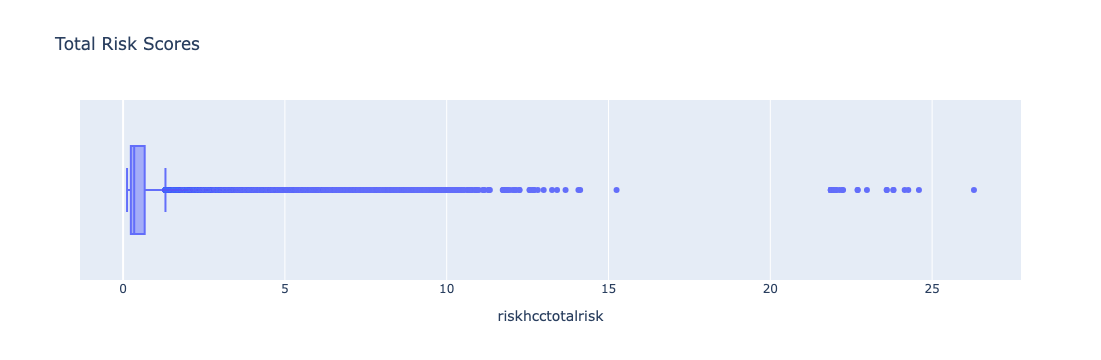

In [69]:
fig = px.box(risks,
                   x='riskhcctotalrisk',
                   #nbins=50,
                   title='Total Risk Scores')

fig.show()

In [7]:
op_agg = gt_op.groupby('deid_personid').agg(
    total_op_cost=('cost', 'sum'),
    op_visit_count=('eventdate', 'count'),
    avg_cost_per_visit=('cost', 'mean')
).reset_index()
op_agg

,deid_personid,total_op_cost,op_visit_count,avg_cost_per_visit
0,00005c8c0136e5d1e49f50700c83ccf7,2839.15,7,405.592857
1,0000672cf36fc1586ff74101e9ee3d6e,3690.22,20,184.511000
2,00006961e0cd7e393b6075560382cfd4,3045.54,6,507.590000
3,0000e6a86c13982bddcaab914d3d127b,1064.98,8,133.122500
4,0000e96e2625f9ff3cff108d1a079afe,461.08,14,32.934286
...,...,...,...,...
326480,ffff9e6383259898a8e75a2a12990c5d,190.65,2,95.325000
326481,ffffa8d43ecb5f4abb02fd6519ede0f1,18731.95,52,360.229808
326482,ffffc5ced058b09c8876b694533c2131,1939.52,10,193.952000
326483,ffffd7bf8c9e34de828bf4a16219a840,868.28,7,124.040000


In [8]:
visit_threshold = op_agg['op_visit_count'].quantile(0.90)
op_agg['high_op_utilizer'] = (op_agg['op_visit_count'] >= visit_threshold).astype(int)

op_agg

,deid_personid,total_op_cost,op_visit_count,avg_cost_per_visit,high_op_utilizer
0,00005c8c0136e5d1e49f50700c83ccf7,2839.15,7,405.592857,0
1,0000672cf36fc1586ff74101e9ee3d6e,3690.22,20,184.511000,0
2,00006961e0cd7e393b6075560382cfd4,3045.54,6,507.590000,0
3,0000e6a86c13982bddcaab914d3d127b,1064.98,8,133.122500,0
4,0000e96e2625f9ff3cff108d1a079afe,461.08,14,32.934286,0
...,...,...,...,...,...
326480,ffff9e6383259898a8e75a2a12990c5d,190.65,2,95.325000,0
326481,ffffa8d43ecb5f4abb02fd6519ede0f1,18731.95,52,360.229808,1
326482,ffffc5ced058b09c8876b694533c2131,1939.52,10,193.952000,0
326483,ffffd7bf8c9e34de828bf4a16219a840,868.28,7,124.040000,0


In [9]:
diag_counts = (
    gt_op.groupby(['deid_personid', 'primary_icd'])
    .size()
    .reset_index(name='diag_count')
)

repeated_diag = (
    diag_counts[diag_counts['diag_count'] > 1]
    .groupby('deid_personid')
    .size()
    .reset_index(name='repeated_diag_count')
)

op_agg = op_agg.merge(repeated_diag, on='deid_personid', how='left')
op_agg['repeated_diag_count'] = op_agg['repeated_diag_count'].fillna(0)

In [17]:
gt_op = gt_op.sort_values(['deid_personid', 'eventdate'])

gt_op['days_between_visits'] = (
    gt_op.groupby('deid_personid')['eventdate']
    .diff()
    .dt.days
)

gap_features = (
    gt_op.groupby('deid_personid')['days_between_visits']
    .mean()
    .reset_index(name='avg_days_between_visits')
)

op_agg = op_agg.merge(gap_features, on='deid_personid', how='left')
op_agg = op_agg.fillna(0)

Text(0, 0.5, 'Frequency')

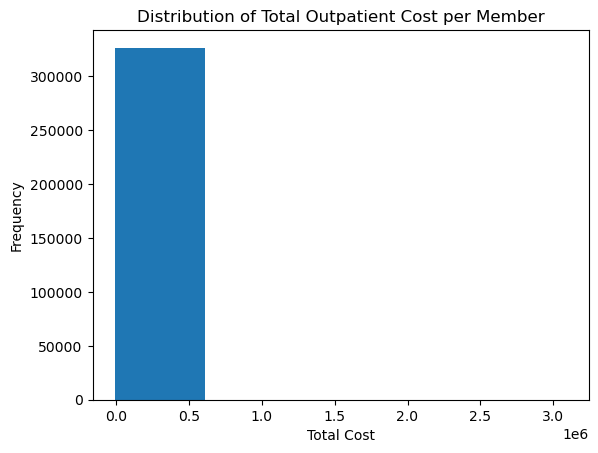

In [22]:
plt.figure()
plt.hist(op_agg['total_op_cost'], bins=5)
plt.title('Distribution of Total Outpatient Cost per Member')
plt.xlabel('Total Cost')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

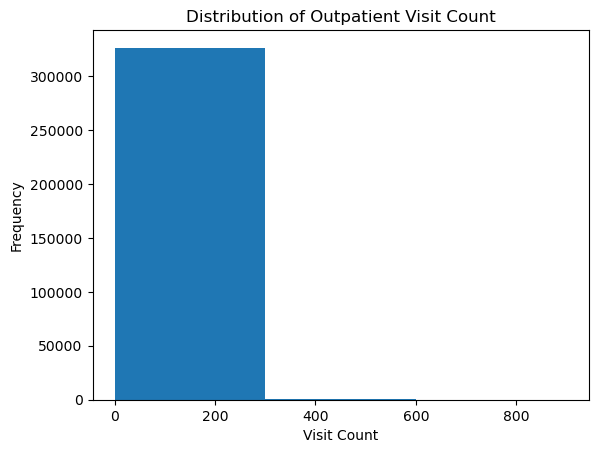

In [25]:
plt.figure()
plt.hist(op_agg['op_visit_count'], bins=3)
plt.title('Distribution of Outpatient Visit Count')
plt.xlabel('Visit Count')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

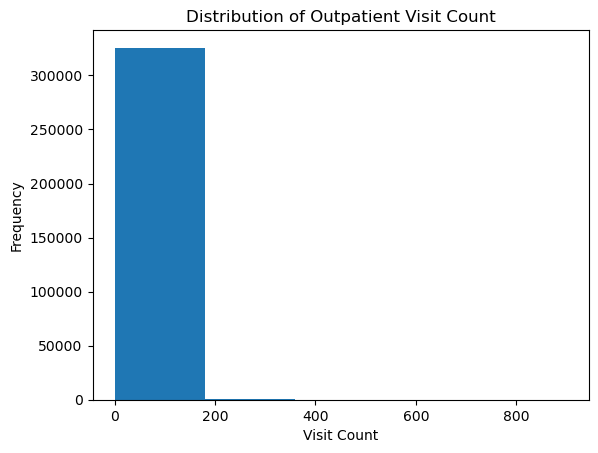

In [27]:
plt.figure()
plt.hist(op_agg['op_visit_count'], bins=5)
plt.title('Distribution of Outpatient Visit Count')
plt.xlabel('Visit Count')
plt.ylabel('Frequency')

Text(0, 0.5, 'Total Cost')

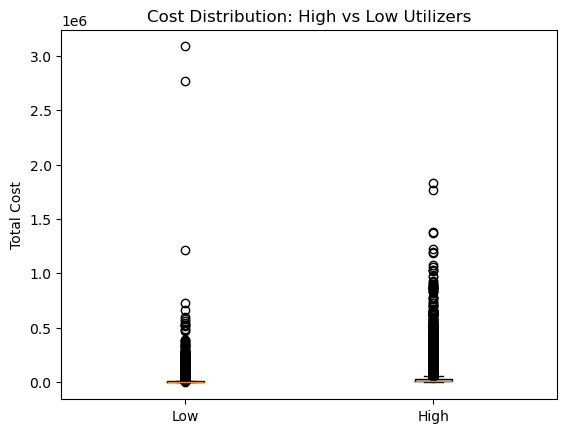

In [28]:
plt.figure()
plt.boxplot([
    op_agg[op_agg['high_op_utilizer'] == 0]['total_op_cost'],
    op_agg[op_agg['high_op_utilizer'] == 1]['total_op_cost']
])
plt.title('Cost Distribution: High vs Low Utilizers')
plt.xticks([1, 2], ['Low', 'High'])
plt.ylabel('Total Cost')

Text(0, 0.5, 'Frequency')

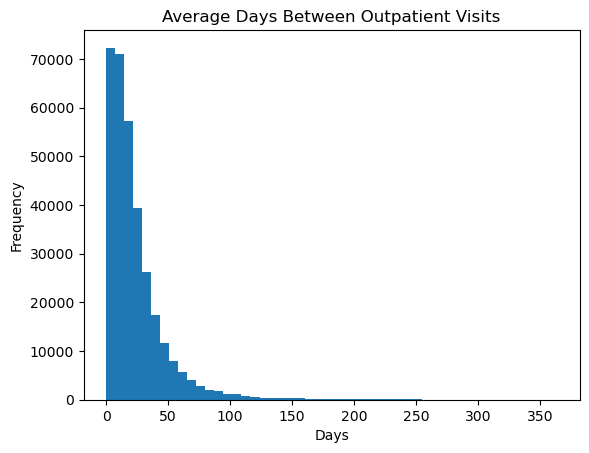

In [29]:
plt.figure()
plt.hist(op_agg['avg_days_between_visits'], bins=50)
plt.title('Average Days Between Outpatient Visits')
plt.xlabel('Days')
plt.ylabel('Frequency')

Text(0, 0.5, 'Total Cost')

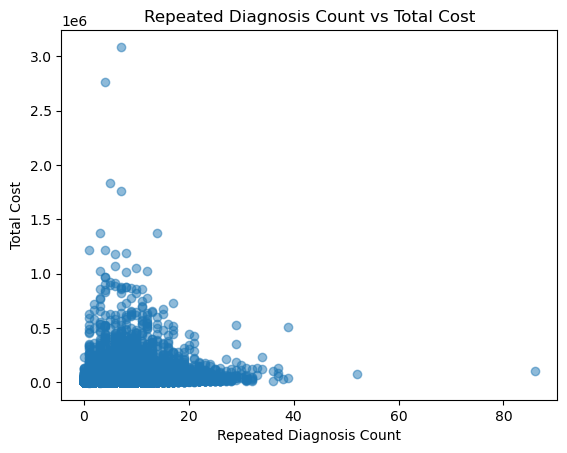

In [30]:
plt.figure()
plt.scatter(op_agg['repeated_diag_count'], op_agg['total_op_cost'], alpha=0.5)
plt.title('Repeated Diagnosis Count vs Total Cost')
plt.xlabel('Repeated Diagnosis Count')
plt.ylabel('Total Cost')

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, 'Frequency')

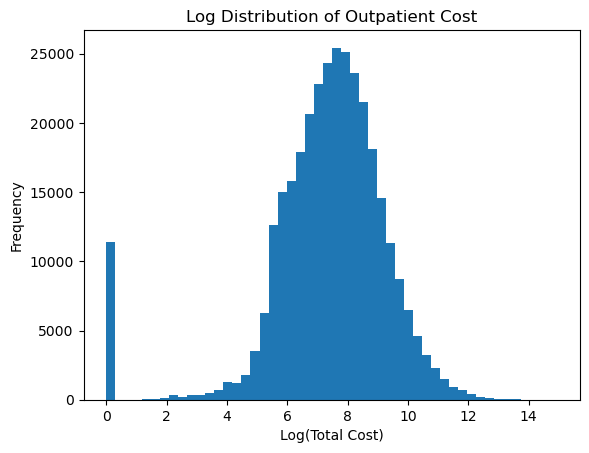

In [31]:
op_agg['log_total_cost'] = np.log1p(op_agg['total_op_cost'])

plt.figure()
plt.hist(op_agg['log_total_cost'], bins=50)
plt.title('Log Distribution of Outpatient Cost')
plt.xlabel('Log(Total Cost)')
plt.ylabel('Frequency')

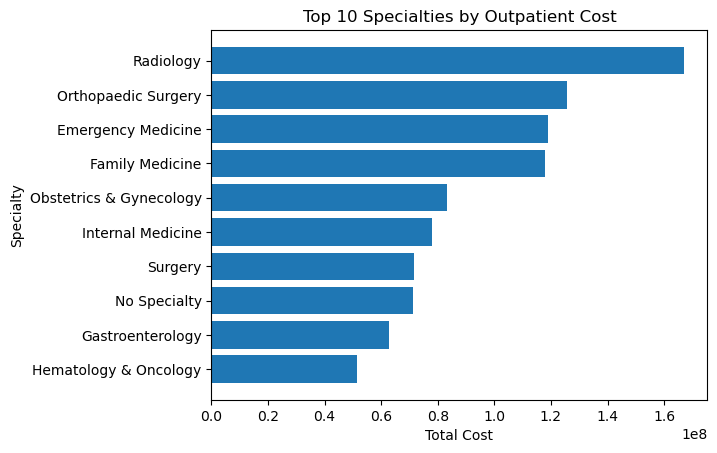

In [32]:
top_specialties = (
    gt_op.groupby('servicing_specialty')['cost']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.barh(top_specialties.index, top_specialties.values)
plt.title('Top 10 Specialties by Outpatient Cost')
plt.xlabel('Total Cost')
plt.ylabel('Specialty')
plt.gca().invert_yaxis()

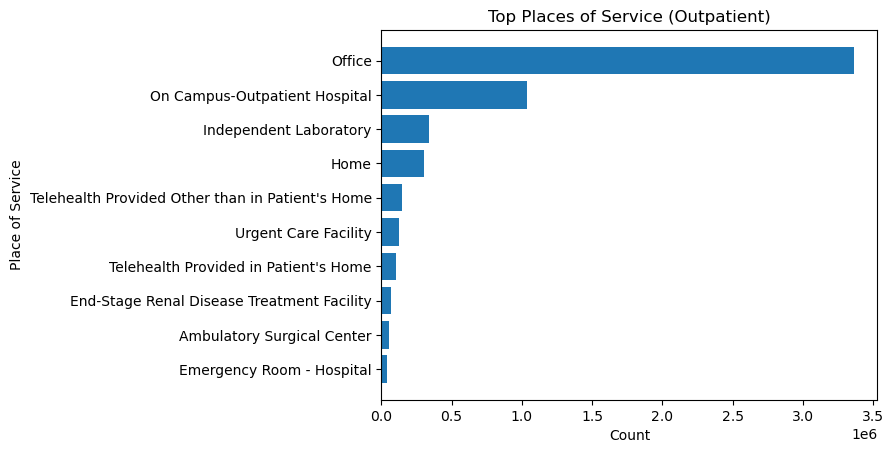

In [33]:
pos_counts = gt_op['placeofservicedescription'].value_counts().head(10)

plt.figure()
plt.barh(pos_counts.index, pos_counts.values)
plt.title('Top Places of Service (Outpatient)')
plt.xlabel('Count')
plt.ylabel('Place of Service')
plt.gca().invert_yaxis()